# Proyek Klasifikasi Gambar: [Diamond Images Dataset](https://www.kaggle.com/datasets/aayushpurswani/diamond-images-dataset/data)
- **Nama:** Andakara Athaya Sidiq
- **Email:** andakaraas@gmail.com
- **ID Dicoding:** andyathsid

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import kagglehub
import shutil
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
import random
from collections import Counter
from PIL import Image
import imghdr
from pathlib import Path
import json
import glob
import re

2025-04-25 05:44:48.535800: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745559888.778991      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745559888.847738      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/tmp/ipykernel_31/2830737197.py:15: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [3]:
print(f'\nTensorflow version = {tf.__version__}\n')
print(f'\n{tf.config.list_physical_devices("GPU")}\n')


Tensorflow version = 2.18.0


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]



In [4]:
!nvidia-smi

Fri Apr 25 05:45:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision training enabled")
except Exception as e:
    print(f"Could not enable mixed precision: {e}")

Mixed precision training enabled


## Data Preparation

### Data Loading

In [6]:
data_dir = "/kaggle/working/data"
os.makedirs(data_dir, exist_ok=True)

In [7]:
path = kagglehub.dataset_download("aayushpurswani/diamond-images-dataset")
files = os.listdir(path)
print(f"File di direktori download: {files}")

for item in files:
    source = os.path.join(path, item)
    destination = os.path.join(data_dir, item)
    
    if os.path.isdir(source):
        shutil.copytree(source, destination, dirs_exist_ok=True)
    else:
        shutil.copy2(source, destination)

print(f"Dataset di-copy ke: {os.path.abspath(data_dir)}")

try:
    if os.path.isdir(path):
        shutil.rmtree(path)
    else:
        os.unlink(path)
    print(f"Data asli pada {path} berhasil dihapus.")
except Exception as e:
    print(f"Data asli gagal dihapus: {e}")

File di direktori download: ['web_scraped']
Dataset di-copy ke: /kaggle/working/data
Data asli gagal dihapus: [Errno 30] Read-only file system: '2014906.jpg'


In [8]:
base_dir = data_dir + "/web_scraped"

In [9]:
def remove_non_image_files(directory):
    image_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}
    removed_count = 0
    
    for root, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            _, ext = os.path.splitext(file_path.lower())
            
            if ext not in image_extensions:
                print(f"Mengapus file non-gambar: {file_path}")
                os.remove(file_path)
                removed_count += 1
    
    return removed_count

removed_files = remove_non_image_files(base_dir)
print(f"File {removed_files} dihapus")

Mengapus file non-gambar: /kaggle/working/data/web_scraped/diamond_data.csv
File 1 dihapus


In [10]:
def validate_images(data_dir):
    img_type_accepted_by_tf = ["bmp", "gif", "jpeg", "png"]
    
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.gif']
    
    invalid_images = []
    
    for filepath in Path(data_dir).rglob("*"):
        if filepath.is_file() and filepath.suffix.lower() in image_extensions:
            img_type = imghdr.what(filepath)
            if img_type is None:
                print(f"{filepath} tidak valid")
                invalid_images.append(filepath)
            elif img_type not in img_type_accepted_by_tf:
                print(f"{filepath} is a {img_type}, tidak kompatibel dengan TensorFlow")
                invalid_images.append(filepath)

    for filepath in invalid_images:
        filepath.unlink()
        print(f"File invalid {len(invalid_images)} berhasil dihapus")

In [11]:
validate_images(base_dir)

/kaggle/working/data/web_scraped/emerald/220188-630.jpg tidak valid
File invalid 1 berhasil dihapus


In [12]:
os.listdir(base_dir)

['oval',
 'emerald',
 'princess',
 'heart',
 'pear',
 'round',
 'cushion',
 'marquise']

In [13]:
classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
print(f"Ditemukan {len(classes)} kelas: {classes}")

Ditemukan 8 kelas: ['oval', 'emerald', 'princess', 'heart', 'pear', 'round', 'cushion', 'marquise']


In [14]:
def check_image_resolutions(base_dir, sample_size=50):
    resolutions = []
    image_paths = []
    class_images = {}
    
    for class_name in classes:
        class_dir = os.path.join(base_dir, class_name)
        image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        sample_files = random.sample(image_files, min(sample_size, len(image_files)))
        
        for img_file in sample_files:
            img_path = os.path.join(class_dir, img_file)
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    resolutions.append((width, height))
                    image_paths.append(img_path)
                    
                    if class_name not in class_images:
                        class_images[class_name] = []
                    
                    if len(class_images[class_name]) < 3: 
                        class_images[class_name].append(img_path)
            except Exception as e:
                print(f"Error dengan {img_path}: {e}")
    
    return resolutions, image_paths, class_images

In [15]:
resolutions, image_paths, class_images = check_image_resolutions(base_dir)

In [16]:
resolution_counts = Counter(resolutions)
most_common_resolutions = resolution_counts.most_common(10)

In [17]:
print(f"Ditemukan {len(set(resolutions))} dengan resolusi gambar berbeda di sampel data")
print("\nTop 10 resolusi:")
for res, count in most_common_resolutions:
    print(f"  {res[0]}×{res[1]} pixel: {count} gambar")

Ditemukan 42 dengan resolusi gambar berbeda di sampel data

Top 10 resolusi:
  600×474 pixel: 90 gambar
  600×472 pixel: 78 gambar
  600×473 pixel: 58 gambar
  600×475 pixel: 41 gambar
  600×471 pixel: 40 gambar
  566×445 pixel: 9 gambar
  518×405 pixel: 6 gambar
  577×454 pixel: 6 gambar
  567×444 pixel: 6 gambar
  528×415 pixel: 6 gambar


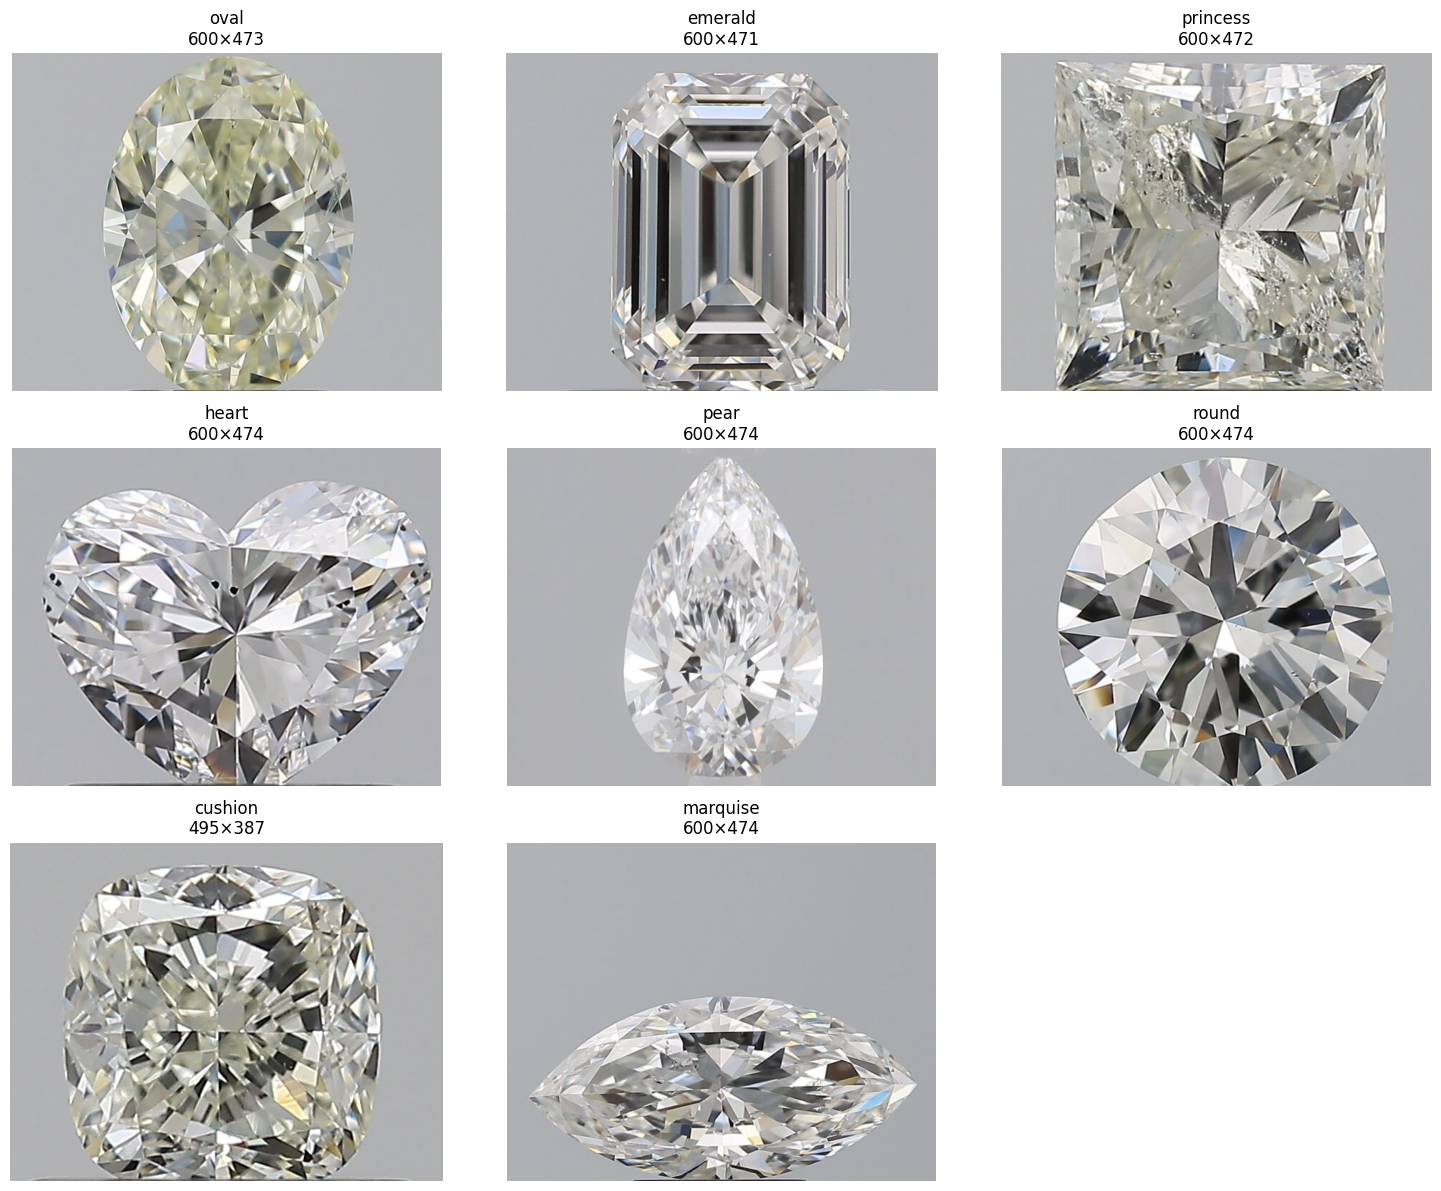

In [18]:
plt.figure(figsize=(15, 12))
row_count = (len(classes) + 2) // 3 

for idx, class_name in enumerate(classes):
    if class_name in class_images:
        sample_paths = class_images[class_name]
        for i, img_path in enumerate(sample_paths):
            plt.subplot(row_count, 3, idx + 1)
            img = Image.open(img_path)
            plt.imshow(img)
            plt.title(f"{class_name}\n{img.width}×{img.height}")
            plt.axis('off')
            break 

plt.tight_layout()
plt.show()

In [19]:
total_count = 0
class_counts = {}

classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

for class_name in classes:
    class_dir = os.path.join(base_dir, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
    class_count = len(image_files)
    
    class_counts[class_name] = class_count
    total_count += class_count
    
print(f"Total gambar di dataset: {total_count}")

Total gambar di dataset: 48764


In [20]:
test_dir = os.path.join('/kaggle/working/data', "test")
os.makedirs(test_dir, exist_ok=True)

In [21]:
sampled_images = {}

for class_name in classes:
    class_dir = os.path.join(base_dir, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if image_files:
        random.seed(42)
        sample_image = random.choice(image_files)
        source_path = os.path.join(class_dir, sample_image)

        dest_filename = f"{class_name}_{sample_image}"
        dest_path = os.path.join(test_dir, dest_filename)
        
        shutil.copy2(source_path, dest_path)
        os.remove(source_path)
        sampled_images[class_name] = dest_path
        print(f"Diambil sampel {class_name}: {sample_image} → {dest_path}")
    else:
        print(f"Gambar tidak ditemukan untuk kelas {class_name}")

print(f"\nGambar sampel disimpan ke: {os.path.abspath(test_dir)}")

Diambil sampel oval: 223304-499.jpg → /kaggle/working/data/test/oval_223304-499.jpg
Diambil sampel emerald: 223431-539.jpg → /kaggle/working/data/test/emerald_223431-539.jpg
Diambil sampel princess: 2119651.jpg → /kaggle/working/data/test/princess_2119651.jpg
Diambil sampel heart: 2089839.jpg → /kaggle/working/data/test/heart_2089839.jpg
Diambil sampel pear: 2130198.jpg → /kaggle/working/data/test/pear_2130198.jpg
Diambil sampel round: 222168-198.jpg → /kaggle/working/data/test/round_222168-198.jpg
Diambil sampel cushion: 2138189.jpg → /kaggle/working/data/test/cushion_2138189.jpg
Diambil sampel marquise: 220569-202.jpg → /kaggle/working/data/test/marquise_220569-202.jpg

Gambar sampel disimpan ke: /kaggle/working/data/test


**✅ Submission Progress Tracker:**
- [x] Gambar-gambar pada dataset asli memiliki resolusi yang tidak seragam (Tanpa preprocessing).
- [x] Dataset yang digunakan berisi minimal 10000 gambar.
- [ ] Akurasi pada training set dan testing set minimal 95%.
- [x] Memiliki 3 buah kelas atau lebih.
- [ ] Melakukan inference menggunakan salah satu model (TF-Lite, TFJS atau savedmodel).


### Data Preprocessing

#### Split Dataset

In [22]:
batch_size = 8
img_height = 224  
img_width = 224   

train_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.4,  
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

temp_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.4,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_batches = len(temp_dataset) // 2
test_batches = len(temp_dataset) - val_batches

validation_dataset = temp_dataset.take(val_batches)
test_dataset = temp_dataset.skip(val_batches)

Found 48756 files belonging to 8 classes.
Using 29254 files for training.


I0000 00:00:1745560147.950865      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745560147.951573      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 48756 files belonging to 8 classes.
Using 19502 files for validation.


In [23]:
class_names = train_dataset.class_names
print(f"Nama kelas: {class_names}")
print(f"Train dataset:- {len(train_dataset)} batch")
print(f"Validation dataset: - {len(validation_dataset)} batch")
print(f"Test dataset: - {len(test_dataset)} batch")

Nama kelas: ['cushion', 'emerald', 'heart', 'marquise', 'oval', 'pear', 'princess', 'round']
Train dataset:- 3657 batch
Validation dataset: - 1219 batch
Test dataset: - 1219 batch


In [24]:
train_samples = len(train_dataset) * batch_size
val_samples = len(validation_dataset) * batch_size
test_samples = len(test_dataset) * batch_size
total_samples = train_samples + val_samples + test_samples

In [25]:
print(f"Training: {train_samples} sampel ({train_samples/total_samples:.1%})")
print(f"Validation: {val_samples} sampel ({val_samples/total_samples:.1%})")
print(f"Test: {test_samples} sampel ({test_samples/total_samples:.1%})")

Training: 29256 sampel (60.0%)
Validation: 9752 sampel (20.0%)
Test: 9752 sampel (20.0%)


In [26]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [27]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.1),
  tf.keras.layers.RandomZoom(0.1),
  tf.keras.layers.RandomContrast(0.2),
])

In [28]:
num_classes = len(class_names)

In [29]:
def augment(images, labels):
    images = data_augmentation(images)
    return images, labels

train_dataset = train_dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)


## Modelling

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

In [31]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      25,690,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 256)                 │           1,0

 Total params: 26,217,416 (100.01 MB)

 Trainable params: 26,214,920 (100.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [33]:
checkpoint_dir = "/kaggle/working/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

In [34]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, 'model_epoch{epoch:02d}_val_acc{val_accuracy:.4f}.weights.h5'),
        save_weights_only=True,
        monitor='val_accuracy',
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=2,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [35]:
if os.path.exists('/kaggle/working/data/web_scraped/diamond_data.csv'):
    os.remove('/kaggle/working/data/web_scraped/diamond_data.csv')

In [36]:
epochs = 10
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10


I0000 00:00:1745560170.500126     104 service.cc:148] XLA service 0x797898035dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745560170.500774     104 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745560170.500787     104 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1745560171.397843     104 cuda_dnn.cc:529] Loaded cuDNN version 90300


   4/3657 ━━━━━━━━━━━━━━━━━━━━ 1:08 19ms/step - accuracy: 0.0964 - loss: 2.3969       

I0000 00:00:1745560180.645039     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3657/3657 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8390 - loss: 0.5231
Epoch 1: val_accuracy improved from -inf to 0.68468, saving model to /kaggle/working/checkpoints/model_epoch01_val_acc0.6847.weights.h5
3657/3657 ━━━━━━━━━━━━━━━━━━━━ 240s 58ms/step - accuracy: 0.8390 - loss: 0.5231 - val_accuracy: 0.6847 - val_loss: 1.3133 - learning_rate: 0.0010
Epoch 2/10
3657/3657 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9470 - loss: 0.1701
Epoch 2: val_accuracy improved from 0.68468 to 0.69340, saving model to /kaggle/working/checkpoints/model_epoch02_val_acc0.6934.weights.h5
3657/3657 ━━━━━━━━━━━━━━━━━━━━ 209s 55ms/step - accuracy: 0.9470 - loss: 0.1701 - val_accuracy: 0.6934 - val_loss: 0.9855 - learning_rate: 0.0010
Epoch 3/10
3656/3657 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9532 - loss: 0.1519
Epoch 3: val_accuracy improved from 0.69340 to 0.98810, saving model to /kaggle/working/checkpoints/model_epoch03_val_acc0.9881.weights.h5
3657/3657 ━━━━━━━━━━━━━━━━━━━━ 210s 56

**✅ Submission Progress Tracker:**
- [x] Mengimplementasikan Callback
- [x] Gambar-gambar pada dataset asli memiliki resolusi yang tidak seragam (Tanpa preprocessing).
- [x] Dataset yang digunakan berisi minimal 10000 gambar.
- [ ] Akurasi pada training set dan testing set minimal 95%.
- [x] Memiliki 3 buah kelas atau lebih.
- [ ] Melakukan inference menggunakan salah satu model (TF-Lite, TFJS atau savedmodel).


## Evaluasi dan Visualisasi

In [37]:
final_epoch = len(history.history['accuracy']) - 1
train_accuracy = history.history['accuracy'][final_epoch] 
train_loss = history.history['loss'][final_epoch]

print(f"Akurasi training: {train_accuracy:.4f}")

Akurasi training: 0.9781


In [38]:
best_val_acc_idx = np.argmax(history.history['val_accuracy'])
best_val_acc = history.history['val_accuracy'][best_val_acc_idx]
print(f"Akurasi Validasi Terbaik: {best_val_acc:.4f} (epoch {best_val_acc_idx+1})")

Akurasi Validasi Terbaik: 0.9908 (epoch 4)


In [39]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Akurasi test: {test_accuracy:.4f}")

1219/1219 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9871 - loss: 0.0672
Akurasi test: 0.9881


In [40]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    batch_preds = model.predict(images, verbose=0)
    batch_pred_classes = np.argmax(batch_preds, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(batch_pred_classes)

In [41]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

report = classification_report(
    y_true, 
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

     cushion     0.9378    0.9851    0.9609      1072
     emerald     1.0000    0.9912    0.9956       681
       heart     0.9987    1.0000    0.9994       776
    marquise     0.9861    0.8554    0.9161        83
        oval     0.9884    0.9953    0.9919      1286
        pear     0.9709    0.9890    0.9799       912
    princess     1.0000    0.9207    0.9587       794
       round     0.9993    0.9990    0.9992      4146

    accuracy                         0.9880      9750
   macro avg     0.9852    0.9670    0.9752      9750
weighted avg     0.9884    0.9880    0.9879      9750



In [42]:
cm = confusion_matrix(y_true, y_pred, normalize="true")

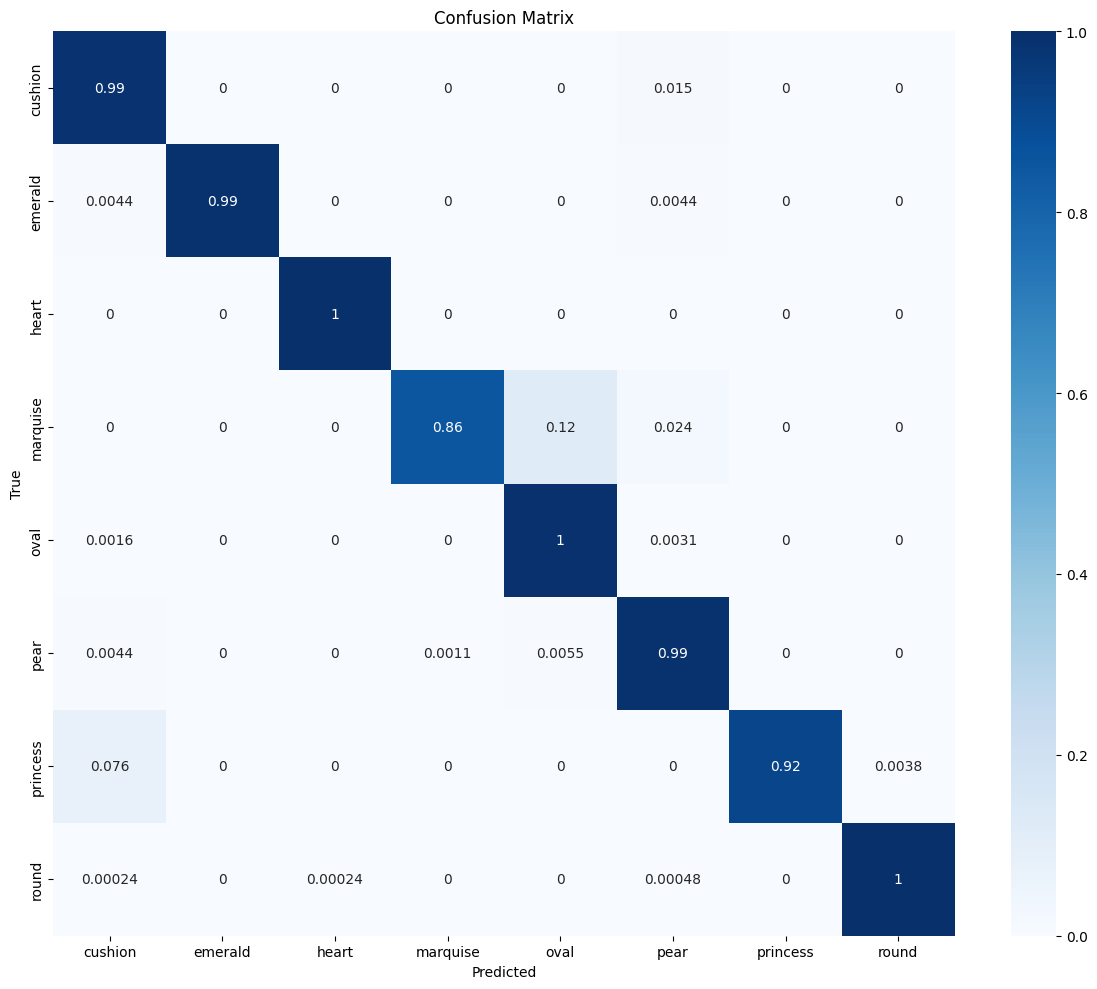

In [43]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True, 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()


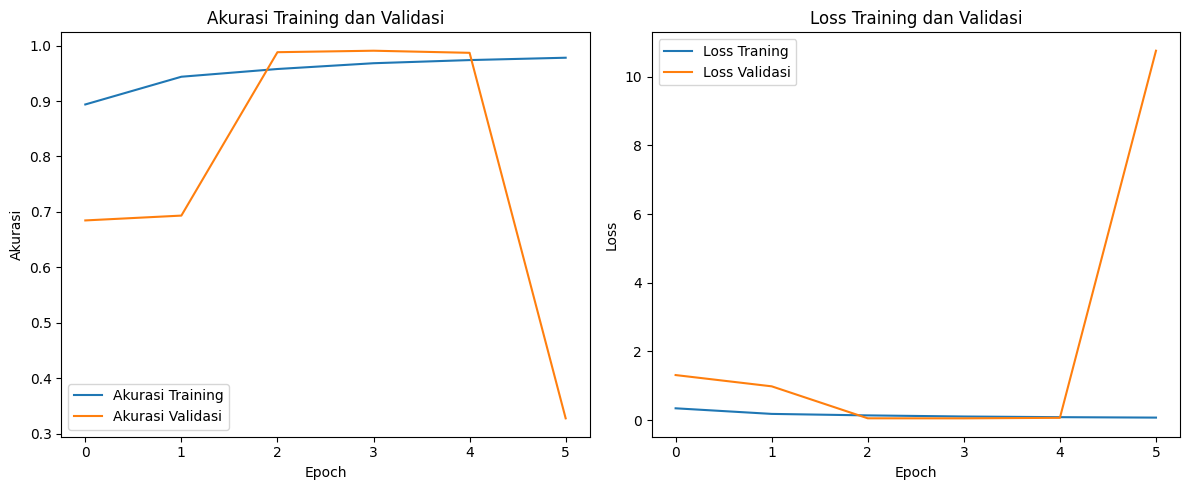

In [44]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Akurasi Training')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.title('Akurasi Training dan Validasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Traning')
plt.plot(history.history['val_loss'], label='Loss Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Training dan Validasi')
plt.legend()

plt.tight_layout()
plt.show()

**✅ Submission Progress Tracker:**
- [x] Mengimplementasikan Callback
- [x] Gambar-gambar pada dataset asli memiliki resolusi yang tidak seragam (Tanpa preprocessing).
- [x] Dataset yang digunakan berisi minimal 10000 gambar.
- [x] Akurasi pada training set dan testing set minimal 95%.
- [x] Memiliki 3 buah kelas atau lebih.
- [ ] Melakukan inference menggunakan salah satu model (TF-Lite, TFJS atau savedmodel).


## Konversi Model

In [53]:
os.makedirs('/kaggle/working/model/', exist_ok=True)
model.save('/kaggle/working/model/model.keras')

### SavedModel

In [54]:
saved_model_dir = "model/saved_model"
model.export(saved_model_dir, 'tf_saved_model')

Saved artifact at 'model/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float16, name=None)
Captures:
  133562578854032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562578861904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562579148752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562579141264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562578855184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562578853840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562579142608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562579141456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562579141840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133562579143952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13356257914

### TF-Lite

In [55]:
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)

In [56]:
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, 
    tf.lite.OpsSet.SELECT_TF_OPS  
]


In [57]:
tflite_model = converter.convert()

W0000 00:00:1745562055.568856      31 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1745562055.568905      31 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [58]:
model_path = "model/tflite_model/diamond_classifier.tflite"
os.makedirs(os.path.dirname(model_path), exist_ok=True)
with tf.io.gfile.GFile(model_path, 'wb') as f:
    f.write(tflite_model)

### TFJS

In [59]:
!pip install tensorflowjs

In [60]:
tfjs_dir = "/kaggle/working/model/tfjs_model"
!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model {saved_model_dir} {tfjs_dir}
print(f"Model berhasil dikonversi ke TensorFlow.js format di: {tfjs_dir}")

2025-04-25 06:21:03.325776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745562063.346107   10237 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745562063.352421   10237 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
I0000 00:00:1745562067.919397   10237 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12768 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745562067.920055   10237 gpu_device.cc:2022] Created device /job:localhost/replica:0

## Inference (Optional)

In [61]:
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

INFO: Created TensorFlow Lite delegate for select TF ops.
I0000 00:00:1745562203.517327      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745562203.517611      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
INFO: TfLiteFlexDelegate delegate: 26 nodes delegated out of 52 nodes with 8 partitions.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [62]:
def preprocess_image(img_path):
    img = Image.open(img_path).convert('RGB')
    img = img.resize((img_height, img_width))
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img
    
test_dir = "/kaggle/working/data/test"
test_images = [os.path.join(test_dir, f) for f in os.listdir(test_dir) 
               if os.path.isfile(os.path.join(test_dir, f)) and 
               f.lower().endswith(('.png', '.jpg', '.jpeg'))]


Gambar: princess_2119651.jpg
Actual: princess | Predicted: princess (0.9658) ✓
Top 3 prediksi:
  - princess: 0.9658
  - cushion: 0.0285
  - round: 0.0053

Gambar: emerald_223431-539.jpg
Actual: emerald | Predicted: emerald (1.0000) ✓
Top 3 prediksi:
  - emerald: 1.0000
  - cushion: 0.0000
  - round: 0.0000

Gambar: heart_2089839.jpg
Actual: heart | Predicted: heart (1.0000) ✓
Top 3 prediksi:
  - heart: 1.0000
  - round: 0.0001
  - princess: 0.0000

Gambar: marquise_220569-202.jpg
Actual: marquise | Predicted: marquise (0.8867) ✓
Top 3 prediksi:
  - marquise: 0.8867
  - oval: 0.0657
  - pear: 0.0475

Gambar: cushion_2138189.jpg
Actual: cushion | Predicted: cushion (0.9922) ✓
Top 3 prediksi:
  - cushion: 0.9922
  - round: 0.0079
  - heart: 0.0000

Gambar: pear_2130198.jpg
Actual: pear | Predicted: pear (1.0000) ✓
Top 3 prediksi:
  - pear: 1.0000
  - cushion: 0.0001
  - oval: 0.0000

Gambar: oval_223304-499.jpg
Actual: oval | Predicted: oval (0.9971) ✓
Top 3 prediksi:
  - oval: 0.9971
  

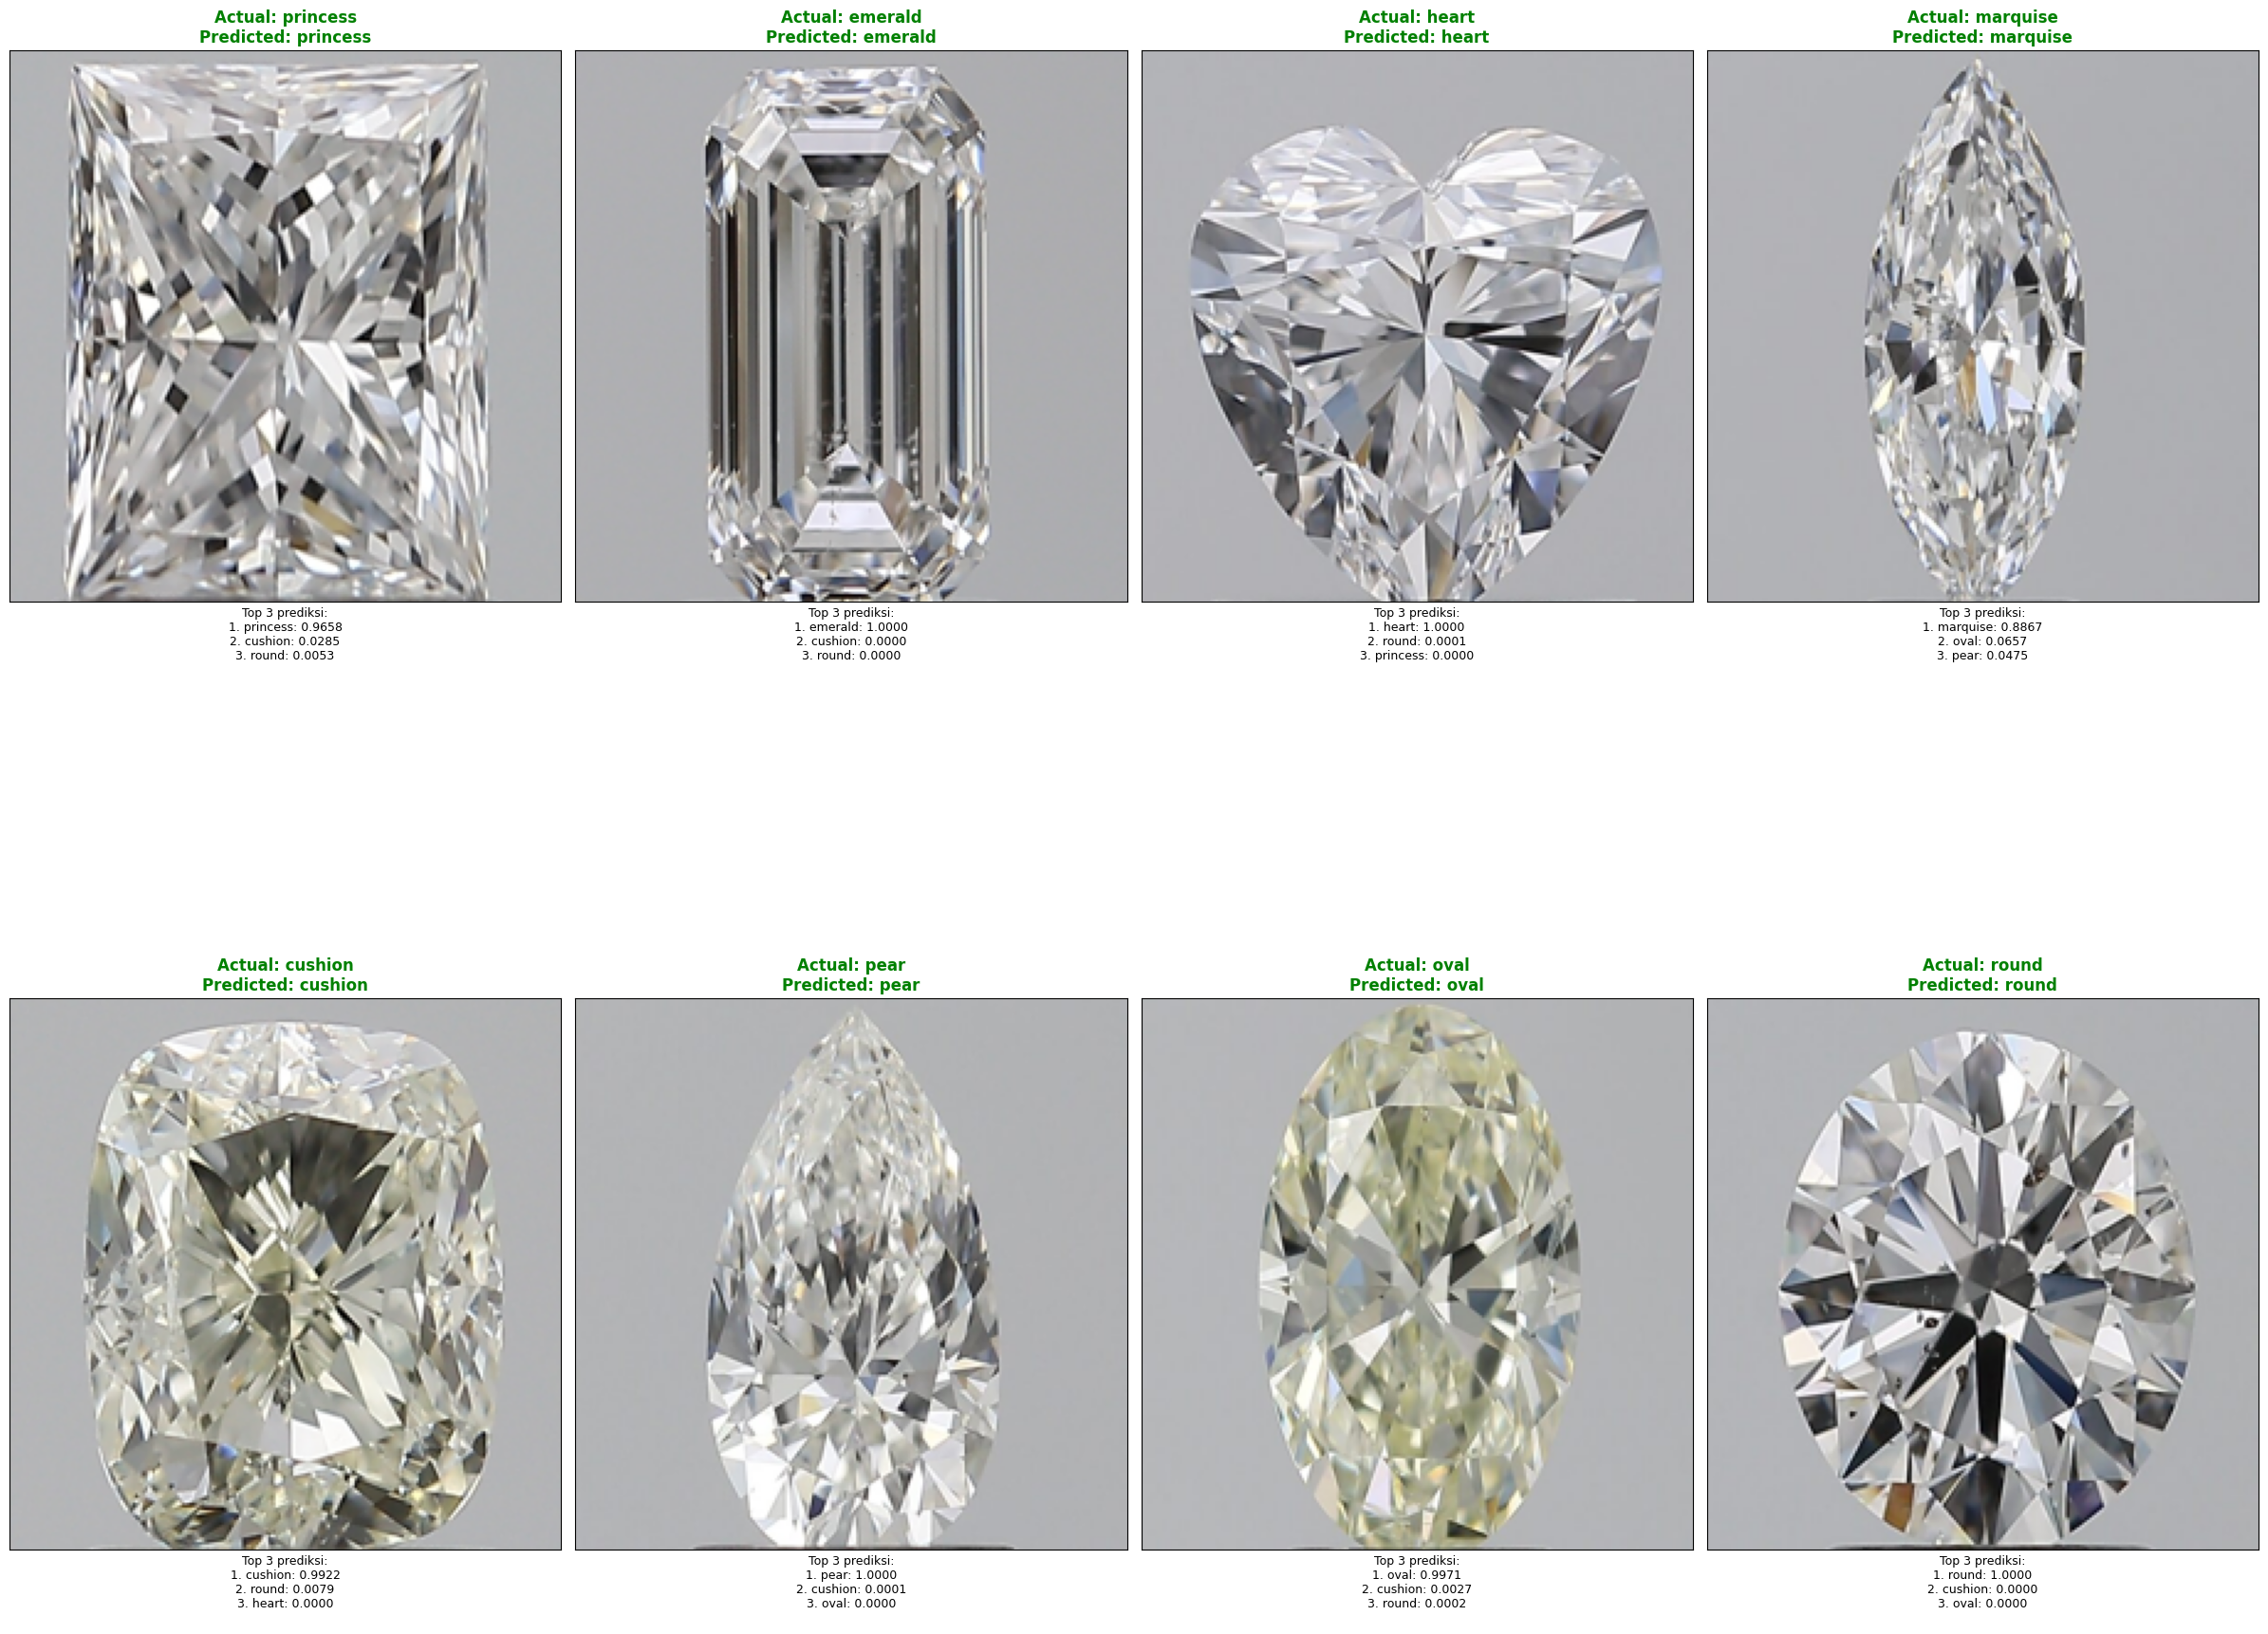

In [64]:
plt.figure(figsize=(24, 18))
plt.subplots_adjust(hspace=0.6, wspace=0.3)
rows = 2
cols = 4

for i, img_path in enumerate(test_images):
    img_name = os.path.basename(img_path)
    actual_class = img_name.split('_')[0]
    
    input_data, original_img = preprocess_image(img_path)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    
    predicted_class = np.argmax(output_data[0])
    confidence = output_data[0][predicted_class]
    predicted_class_name = class_names[predicted_class]
    
    top_indices = np.argsort(output_data[0])[-3:][::-1]
    top_predictions = [(class_names[idx], float(output_data[0][idx])) for idx in top_indices]
    
    is_correct = actual_class == predicted_class_name
    color = 'green' if is_correct else 'red'
    
    plt.subplot(rows, cols, i+1)
    plt.imshow(original_img)
    
    title = f"Actual: {actual_class}\nPredicted: {predicted_class_name}"
    plt.title(title, color=color, fontweight='bold', fontsize=12)
    
    info_text = "Top 3 prediksi:\n"
    for idx, (name, score) in enumerate(top_predictions):
        info_text += f"{idx+1}. {name}: {score:.4f}\n"
    
    plt.xlabel(info_text, fontsize=9)
    plt.xticks([])
    plt.yticks([])
    
    print(f"\nGambar: {img_name}")
    result_mark = "✓" if is_correct else "✗"
    print(f"Actual: {actual_class} | Predicted: {predicted_class_name} ({confidence:.4f}) {result_mark}")
    print("Top 3 prediksi:")
    for class_name, score in top_predictions:
        print(f"  - {class_name}: {score:.4f}")

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()

**✅ Submission Progress Tracker:**
- [x] Mengimplementasikan Callback
- [x] Gambar-gambar pada dataset asli memiliki resolusi yang tidak seragam (Tanpa preprocessing).
- [x] Dataset yang digunakan berisi minimal 10000 gambar.
- [x] Akurasi pada training set dan testing set minimal 95%.
- [x] Memiliki 3 buah kelas atau lebih.
- [x] Melakukan inference menggunakan salah satu model (TF-Lite, TFJS atau savedmodel).


In [65]:
metadata = {
    "class_names": class_names,
    "img_height": img_height,
    "img_width": img_width,
    "model_version": "1.0.0"
}


In [66]:
with open('/kaggle/working/model/tflite_model/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

In [67]:
!zip -r model.zip /kaggle/working/model

  adding: kaggle/working/model/ (stored 0%)
  adding: kaggle/working/model/saved_model/ (stored 0%)
  adding: kaggle/working/model/saved_model/fingerprint.pb (stored 0%)
  adding: kaggle/working/model/saved_model/saved_model.pb (deflated 88%)
  adding: kaggle/working/model/saved_model/variables/ (stored 0%)
  adding: kaggle/working/model/saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: kaggle/working/model/saved_model/variables/variables.index (deflated 72%)
  adding: kaggle/working/model/saved_model/assets/ (stored 0%)
  adding: kaggle/working/model/tfjs_model/ (stored 0%)
  adding: kaggle/working/model/tfjs_model/group1-shard12of26.bin (deflated 40%)
  adding: kaggle/working/model/tfjs_model/group1-shard15of26.bin (deflated 41%)
  adding: kaggle/working/model/tfjs_model/group1-shard20of26.bin (deflated 41%)
  adding: kaggle/working/model/tfjs_model/group1-shard18of26.bin (deflated 40%)
  adding: kaggle/working/model/tfjs_model/group1-shard5of26.bin (deflate

In [70]:
from IPython.display import FileLink
FileLink(r'model.zip')

/kaggle/working/model.zip